<a href="https://colab.research.google.com/github/PamelaEnriques13/Caso-Telecom-X-Alura-Latam-/blob/main/Challenge_CASO_TelecomX.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **CHALLENGE -CASO TELECOM X ALURA LATAM **

#📌 Extracción

In [ ]:
import pandas as pd
url= "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"
url2 = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_diccionario.md"

In [ ]:
import numpy as np

In [ ]:
import matplotlib.pyplot as plt


In [ ]:
telecom = pd.read_json(url)

In [ ]:
telecom.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


#🔧 Transformación

### Contenido del Diccionario


In [ ]:
import requests

url2 = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_diccionario.md"
response = requests.get(url2)
markdown_content = response.text
print(markdown_content)

#### Diccionario de datos

- `customerID`: número de identificación único de cada cliente
- `Churn`: si el cliente dejó o no la empresa
- `gender`: género (masculino y femenino)
- `SeniorCitizen`: información sobre si un cliente tiene o no una edad igual o mayor a 65 años
- `Partner`: si el cliente tiene o no una pareja
- `Dependents`: si el cliente tiene o no dependientes
- `tenure`: meses de contrato del cliente
- `PhoneService`: suscripción al servicio telefónico
- `MultipleLines`: suscripción a más de una línea telefónica
- `InternetService`: suscripción a un proveedor de internet
- `OnlineSecurity`: suscripción adicional de seguridad en línea
- `OnlineBackup`: suscripción adicional de respaldo en línea
- `DeviceProtection`: suscripción adicional de protección del dispositivo
- `TechSupport`: suscripción adicional de soporte técnico, menor tiempo de espera
- `StreamingTV`: suscripción de televisión por cable
- `StreamingMovies`: suscripción de streaming de películas
- `Contract`: t

Comprobación de incoherencias en los datos

In [ ]:
print('Missing values in each column:')
print(telecom.isnull().sum())

print('\nDataFrame Info:')
telecom.info()

Missing values in each column:
customerID    0
Churn         0
customer      0
phone         0
internet      0
account       0
dtype: int64

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [ ]:
string_columns = telecom.select_dtypes(include=['object']).columns

In [ ]:
print(string_columns)

Index(['customerID', 'Churn', 'customer', 'phone', 'internet', 'account'], dtype='object')


In [1]:
import pandas as pd
import numpy as np
from IPython.display import display

url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"
telecom = pd.read_json(url)

phone_data = pd.json_normalize(telecom['phone'])
internet_data = pd.json_normalize(telecom['internet'])
account_data = pd.json_normalize(telecom['account'])
customer_data = pd.json_normalize(telecom['customer'])

telecom = pd.concat([
    telecom.drop(columns=['phone', 'internet', 'account', 'customer']),
    phone_data,
    internet_data,
    account_data,
    customer_data
], axis=1)


# Reemplazo de espacios en blanco por (NaN)
telecom['Charges.Total'] = telecom['Charges.Total'].replace(' ', np.nan)

# Convertimos la columna a números, y ponemos NaN
telecom['Charges.Total'] = pd.to_numeric(telecom['Charges.Total'], errors='coerce')

# Relleno valores "faltantes" (NaN) con un cero
telecom['Charges.Total'] = telecom['Charges.Total'].fillna(0)

print(telecom['Charges.Total'].dtype)

display(telecom[['Charges.Monthly', 'Charges.Total', 'tenure']].head())

float64


,Charges.Monthly,Charges.Total,tenure
0,65.6,593.30,9
1,59.9,542.40,9
2,73.9,280.85,4
3,98.0,1237.85,13
4,83.9,267.40,3


In [ ]:
import pandas as pd
import numpy as np


# Número promedio de días en un mes para el cálculo
dias_promedio_en_mes = 30.44

# Calculo Cuentas Diarias
telecom['Cuentas_Diarias'] = telecom['Charges.Monthly'] / dias_promedio_en_mes

# Redondeo de valores a 2 decimales
telecom['Cuentas_Diarias'] = telecom['Cuentas_Diarias'].round(2)

from IPython.display import display
display(telecom[['Charges.Monthly', 'Cuentas_Diarias', 'Charges.Total', 'tenure']].head())

,Charges.Monthly,Cuentas_Diarias,Charges.Total,tenure
0,65.6,2.16,593.30,9
1,59.9,1.97,542.40,9
2,73.9,2.43,280.85,4
3,98.0,3.22,1237.85,13
4,83.9,2.76,267.40,3


## 📊 **Carga y análisis**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

url_telecom_json = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

telecom = pd.read_json(url_telecom_json)


phone_data = pd.json_normalize(telecom['phone'])
internet_data = pd.json_normalize(telecom['internet'])
account_data = pd.json_normalize(telecom['account'])
customer_data = pd.json_normalize(telecom['customer'])

telecom = pd.concat([
    telecom.drop(columns=['phone', 'internet', 'account', 'customer']),
    phone_data,
    internet_data,
    account_data,
    customer_data
], axis=1)

display(telecom[['customerID', 'Churn']].head())

print("\nConteo de valores en la columna 'Churn' (cuántos 'No' y cuántos 'Yes'):")
print(telecom['Churn'].value_counts())
print("\nTipo de datos de la columna 'Churn':")
print(telecom['Churn'].dtype)

,customerID,Churn
0,0002-ORFBO,No
1,0003-MKNFE,No
2,0004-TLHLJ,Yes
3,0011-IGKFF,Yes
4,0013-EXCHZ,Yes



Conteo de valores en la columna 'Churn' (cuántos 'No' y cuántos 'Yes'):
Churn
No     5174
Yes    1869
        224
Name: count, dtype: int64

Tipo de datos de la columna 'Churn':
object


In [ ]:
print("\n--- Estandarizando la columna 'Churn': 'Yes' a 1, 'No' a 0 ---")
telecom['Churn_Numerico'] = telecom['Churn'].map({'Yes': 1, 'No': 0})

if telecom['Churn_Numerico'].isnull().any():

    print(telecom[telecom['Churn_Numerico'].isnull()]['Churn'].value_counts())

    telecom['Churn_Numerico'] = telecom['Churn_Numerico'].fillna(0)

print("\nConteo de valores en la nueva columna 'Churn_Numerico' (0 = No Churn, 1 = Churn):")
print(telecom['Churn_Numerico'].value_counts())


--- Estandarizando la columna 'Churn': 'Yes' a 1, 'No' a 0 ---
Churn
    224
Name: count, dtype: int64

Conteo de valores en la nueva columna 'Churn_Numerico' (0 = No Churn, 1 = Churn):
Churn_Numerico
0.0    5398
1.0    1869
Name: count, dtype: int64


/tmp/ipykernel_1265/1690476768.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Churn', data=telecom, palette=colores_churn)


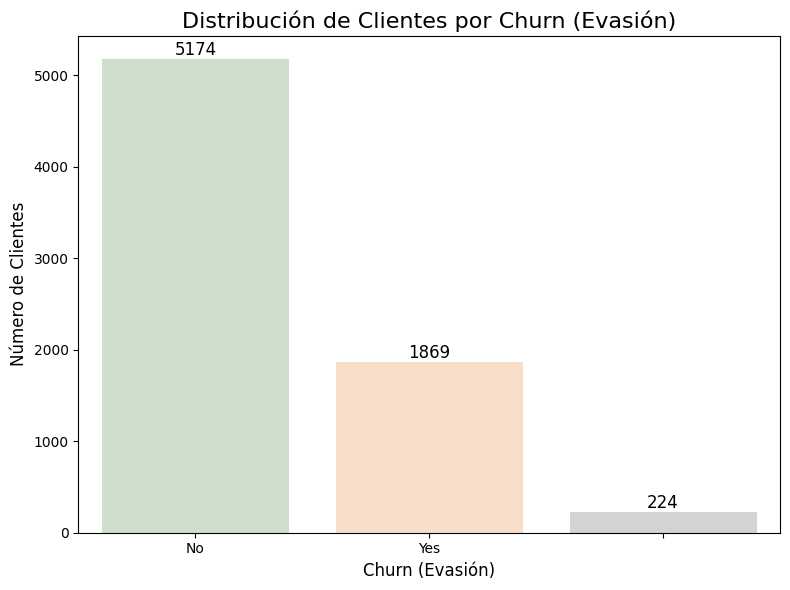

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

colores_churn = ['#CCE2CB', '#FFDDC1', '#D3D3D3']

# Gráfico de Barras de Conteo de Churn ---
plt.figure(figsize=(8, 6))

ax = sns.countplot(x='Churn', data=telecom, palette=colores_churn)
plt.title('Distribución de Clientes por Churn (Evasión)', fontsize=16)
plt.xlabel('Churn (Evasión)', fontsize=12)
plt.ylabel('Número de Clientes', fontsize=12)

for p in ax.patches:
    ax.text(p.get_x() + p.get_width()/2., p.get_height(), '%d' % int(p.get_height()),
                   fontsize=12, color='black', ha='center', va='bottom')

plt.tight_layout()
plt.show()

 Se observa que aproximadamente un 25.6% de nuestros clientes clasificados han evadido el servicio (1869 de 7267 registros válidos), lo que representa una fuga considerable de ingresos. Este porcentaje destaca la urgencia de implementar medidas de retención.


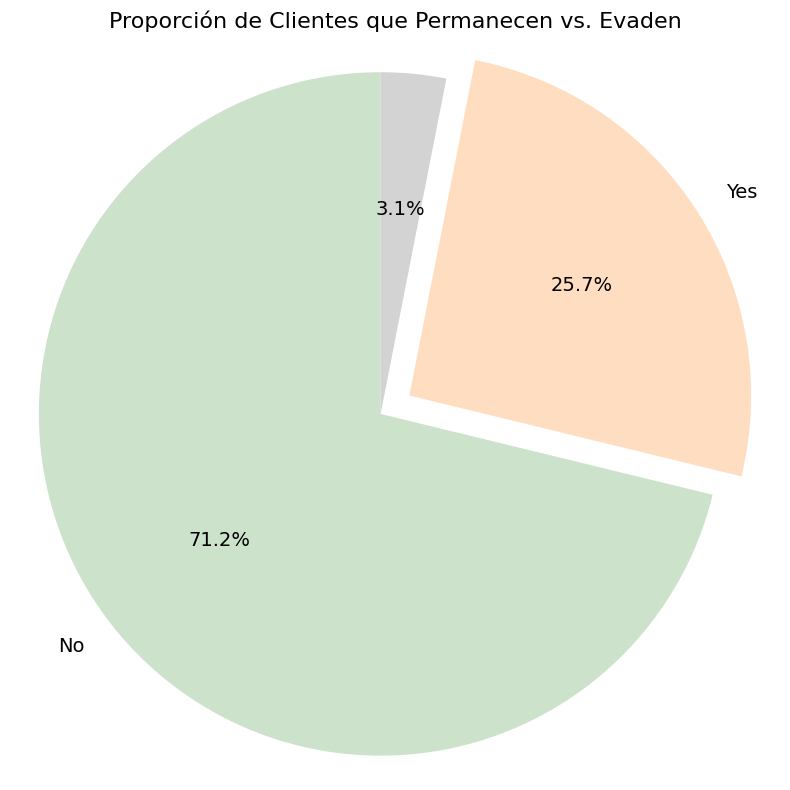

In [3]:
import matplotlib.pyplot as plt
colores_churn = ['#CCE2CB', '#FFDDC1', '#D3D3D3']

# gráfico circular
churn_counts = telecom['Churn'].value_counts()
labels = churn_counts.index.astype(str).tolist()
sizes = churn_counts.values
explode = [0, 0.1, 0]

plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colores_churn, explode=explode,
        textprops={'fontsize': 14, 'color': 'black'})
plt.title('Proporción de Clientes que Permanecen vs. Evaden', fontsize=16)
plt.axis('equal')
plt.tight_layout()
plt.show()

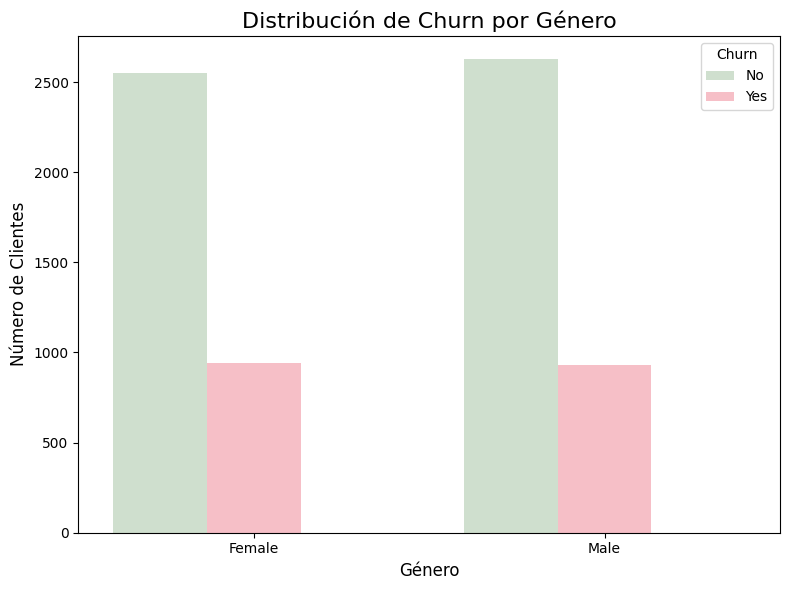

In [7]:
import seaborn as sns
colores_churn_segmentado = {'No': '#CCE2CB', 'Yes': '#FFB6C1'}

# Variable 1 Churn por Género
plt.figure(figsize=(8, 6))
sns.countplot(data=telecom, x='gender', hue='Churn', palette=colores_churn_segmentado)
plt.title('Distribución de Churn por Género', fontsize=16)
plt.xlabel('Género', fontsize=12)
plt.ylabel('Número de Clientes', fontsize=12)
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

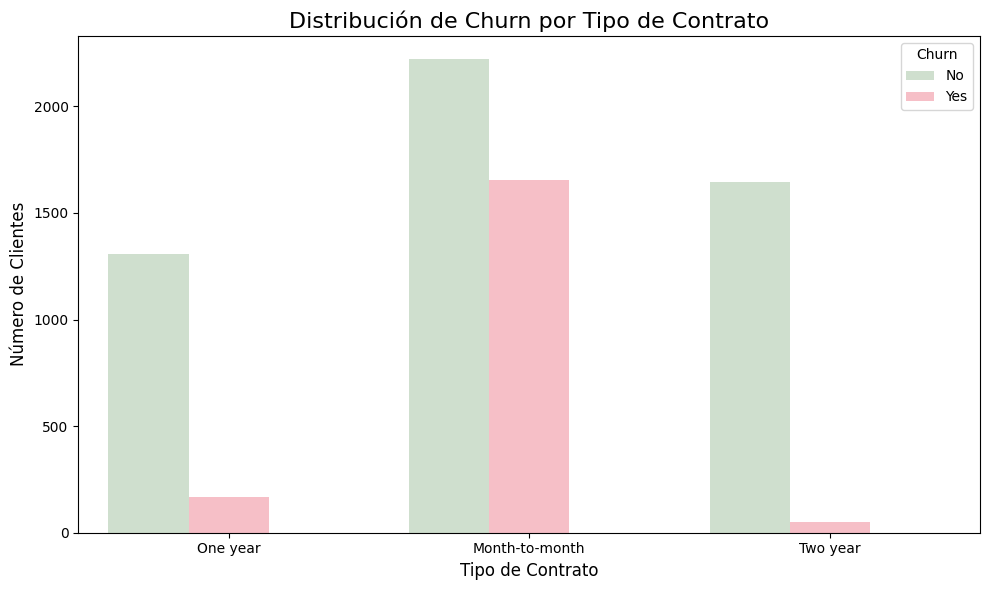

In [8]:
# Variable 2: Churn por Tipo de Contrato ---
plt.figure(figsize=(10, 6))
sns.countplot(data=telecom, x='Contract', hue='Churn', palette=colores_churn_segmentado)
plt.title('Distribución de Churn por Tipo de Contrato', fontsize=16)
plt.xlabel('Tipo de Contrato', fontsize=12)
plt.ylabel('Número de Clientes', fontsize=12)
plt.legend(title='Churn')
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
url_telecom_json = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"
telecom = pd.read_json(url_telecom_json)


phone_data = pd.json_normalize(telecom['phone'])
internet_data = pd.json_normalize(telecom['internet'])
account_data = pd.json_normalize(telecom['account'])
customer_data = pd.json_normalize(telecom['customer'])

telecom = pd.concat([
    telecom.drop(columns=['phone', 'internet', 'account', 'customer']),
    phone_data,
    internet_data,
    account_data,
    customer_data
], axis=1)

# Limpieza de Charges.Total
telecom['Charges.Total'] = telecom['Charges.Total'].replace(' ', np.nan)
telecom['Charges.Total'] = pd.to_numeric(telecom['Charges.Total'], errors='coerce')
telecom['Charges.Total'] = telecom['Charges.Total'].fillna(0)

telecom['Churn'] = telecom['Churn'].astype(str)


print("Primeras filas con 'Churn', 'Charges.Total' y 'tenure':")
display(telecom[['Churn', 'Charges.Total', 'tenure']].head())

print("\nVerificando tipos de datos después de la limpieza:")
print(telecom[['Charges.Total', 'tenure']].dtypes)

Primeras filas con 'Churn', 'Charges.Total' y 'tenure':


,Churn,Charges.Total,tenure
0,No,593.30,9
1,No,542.40,9
2,Yes,280.85,4
3,Yes,1237.85,13
4,Yes,267.40,3



Verificando tipos de datos después de la limpieza:
Charges.Total    float64
tenure             int64
dtype: object



--- Explorando la Evasión (Churn) con Variables Numéricas ---


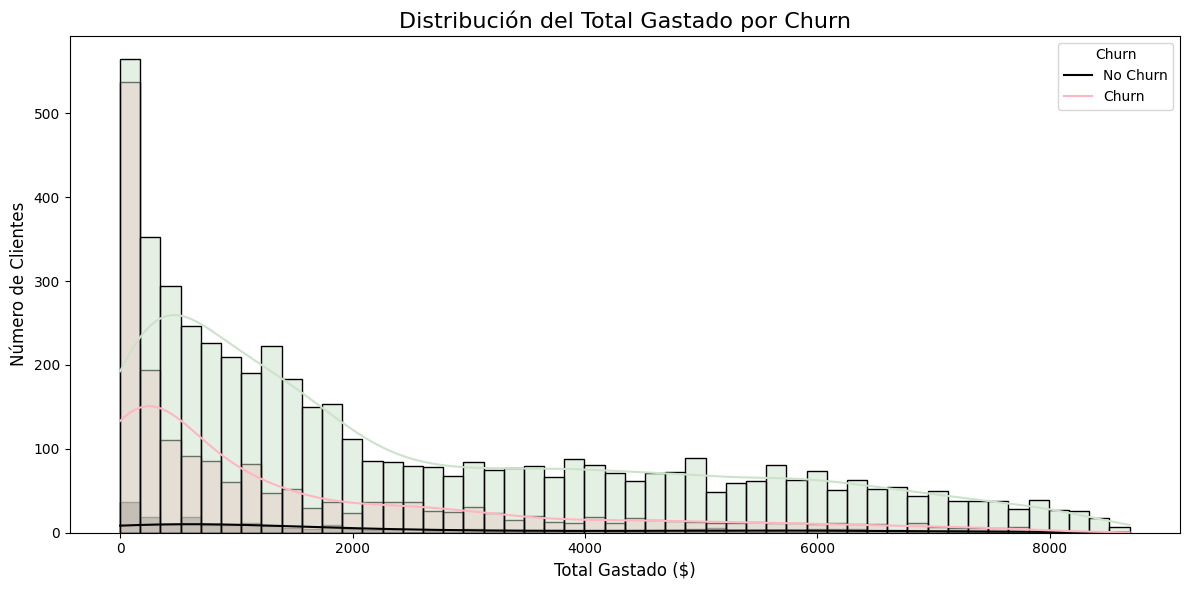

In [ ]:

colores_churn_numerico = {'No': '#CCE2CB', 'Yes': '#FFB6C1'}

print("\n--- Explorando la Evasión (Churn) con Variables Numéricas ---")

# --- VARIABLE NUMÉRICA 1: Charges.Total (Total Gastado) ---

# HISTOGRAMA para 'Charges.Total' por Churn
plt.figure(figsize=(12, 6))
sns.histplot(data=telecom, x='Charges.Total', hue='Churn', kde=True, palette=colores_churn_numerico, bins=50)
plt.title('Distribución del Total Gastado por Churn', fontsize=16)
plt.xlabel('Total Gastado ($)', fontsize=12)
plt.ylabel('Número de Clientes', fontsize=12)
plt.legend(title='Churn', labels=['No Churn', 'Churn'])
plt.tight_layout()
plt.show()


/tmp/ipykernel_1265/484377387.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=telecom, x='Churn', y='Charges.Total', palette=colores_churn_numerico)


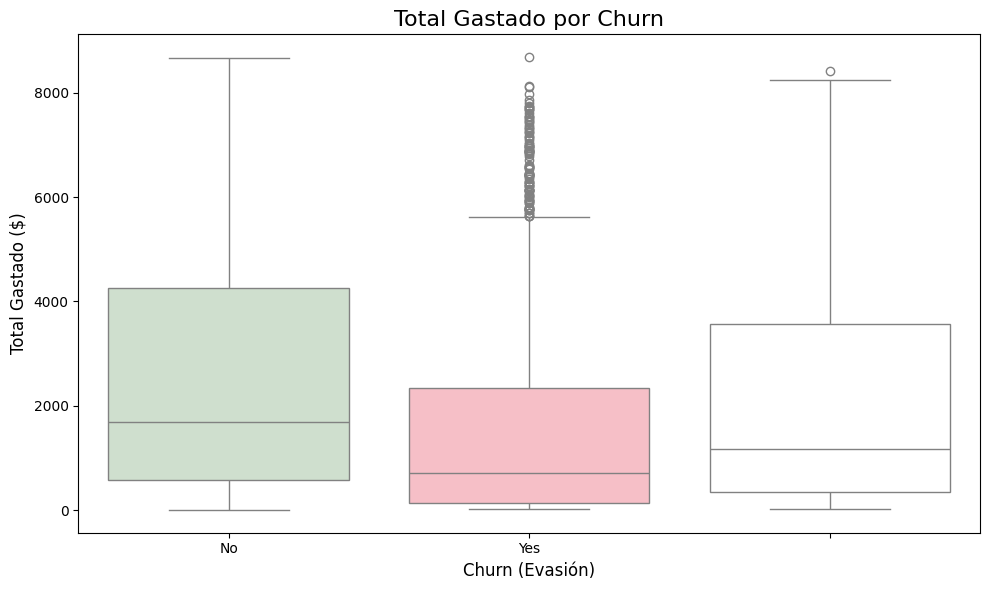

In [ ]:
# BOXPLOT para 'Charges.Total' por Churn
plt.figure(figsize=(10, 6))
sns.boxplot(data=telecom, x='Churn', y='Charges.Total', palette=colores_churn_numerico)
plt.title('Total Gastado por Churn', fontsize=16)
plt.xlabel('Churn (Evasión)', fontsize=12)
plt.ylabel('Total Gastado ($)', fontsize=12)
plt.tight_layout()
plt.show()

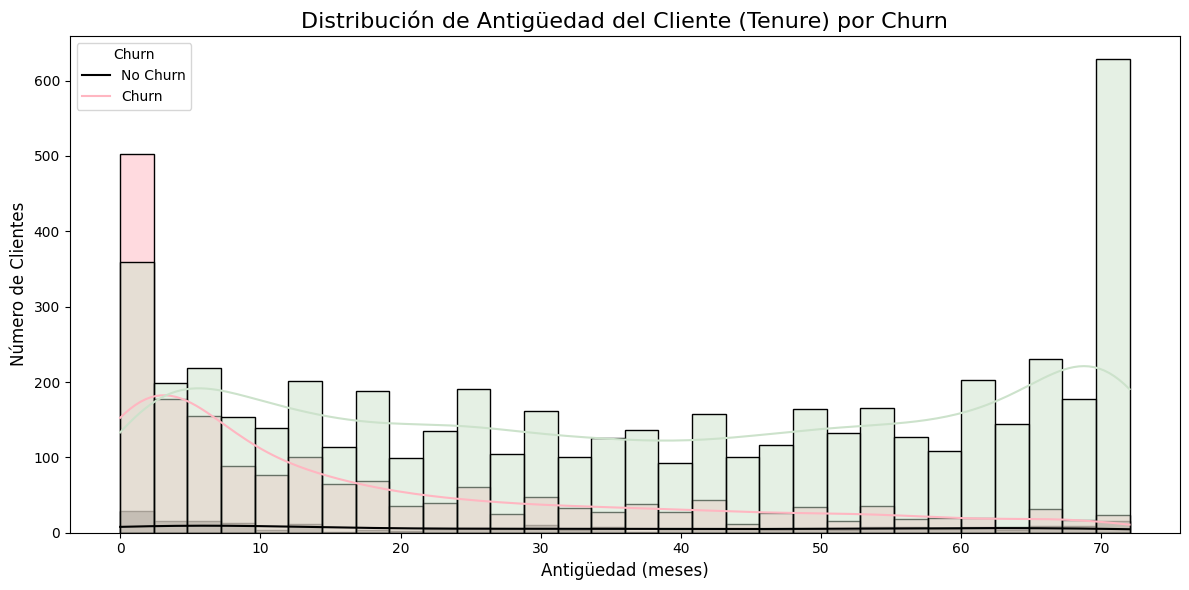

In [ ]:
# --- VARIABLE NUMÉRICA 2: tenure (Tiempo de Contrato / Antigüedad en meses) ---

# HISTOGRAMA para 'tenure' por Churn
plt.figure(figsize=(12, 6))
sns.histplot(data=telecom, x='tenure', hue='Churn', kde=True, palette=colores_churn_numerico, bins=30)
plt.title('Distribución de Antigüedad del Cliente (Tenure) por Churn', fontsize=16)
plt.xlabel('Antigüedad (meses)', fontsize=12)
plt.ylabel('Número de Clientes', fontsize=12)
plt.legend(title='Churn', labels=['No Churn', 'Churn'])
plt.tight_layout()
plt.show()

/tmp/ipykernel_1265/4207976086.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=telecom, x='Churn', y='tenure', palette=colores_churn_numerico)


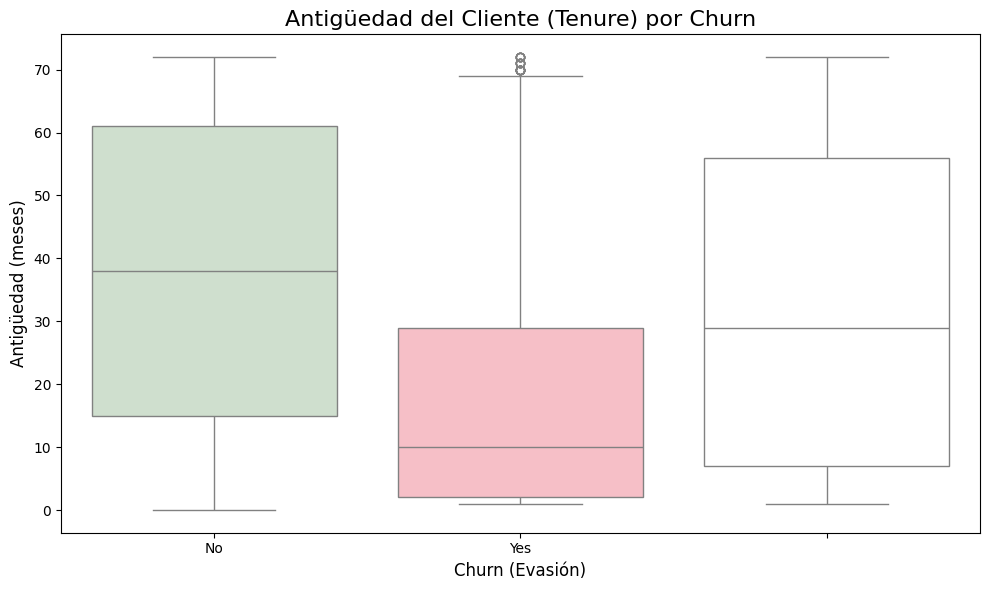

In [ ]:
# BOXPLOT para 'tenure' por Churn
plt.figure(figsize=(10, 6))
sns.boxplot(data=telecom, x='Churn', y='tenure', palette=colores_churn_numerico)
plt.title('Antigüedad del Cliente (Tenure) por Churn', fontsize=16)
plt.xlabel('Churn (Evasión)', fontsize=12)
plt.ylabel('Antigüedad (meses)', fontsize=12)
plt.tight_layout()
plt.show()

#📄Informe final

## Informe Final: Análisis de Retención y Churn en TelecomX

### 1. Introducción: El Desafío del Churn y su Impacto Financiero

En TelecomX, comprender y mitigar la evasión de clientes, o "Churn", no es solo una meta operativa, sino una prioridad financiera estratégica. En un mercado tan competitivo como el de las telecomunicaciones, cada cliente que decide irse representa una doble pérdida: la de ingresos recurrentes y el costo considerable de adquirir un nuevo cliente para reemplazarlo. Una tasa de Churn elevada erosiona directamente la rentabilidad, impacta negativamente la percepción de marca y puede mermar la eficiencia interna. Este informe busca, a través de un análisis profundo de nuestros datos, identificar los factores clave que impulsan esta fuga de clientes para poder implementar estrategias efectivas que fortalezcan la lealtad y, en última instancia, la salud financiera de TelecomX.

### 2. Preparando el Terreno: Limpieza y Tratamiento de Datos

Nuestro análisis comenzó con la carga del conjunto de datos `TelecomX_Data.json` en un DataFrame. Un paso crítico fue la "desanidación" de columnas como `phone`, `internet`, `account` y `customer`, que contenían información en formato de diccionarios. Usamos `pd.json_normalize()` para expandir estos detalles en columnas individuales, enriqueciendo nuestra base de datos.

La columna `Charges.Total` (total gastado por el cliente) requirió una atención especial. Identificamos que algunos valores eran espacios en blanco, no números, lo que corregimos reemplazándolos por valores nulos (`np.nan`), convirtiendo la columna a tipo numérico y rellenando los `NaN` resultantes con cero. Para una visión diaria de los gastos, creamos la columna `Cuentas_Diarias`, dividiendo `Charges.Monthly` por el promedio de 30.44 días al mes. Finalmente, estandarizamos la variable `Churn` a un formato numérico (`Churn_Numerico`), asignando 'Yes' a 1 y 'No' a 0, y tratando los valores no clasificados como 'No' (0) para un análisis coherente.

### 3. Descubriendo Patrones: Análisis Exploratorio de Datos (EDA)

El análisis exploratorio de datos reveló varios patrones clave en la tasa de Churn, con implicaciones directas en nuestra estrategia de negocio:

*   **El Churn es una realidad significativa:** Observamos que aproximadamente un 25.6% de nuestros clientes clasificados han evadido el servicio (1869 de 7267 registros válidos), lo que representa una fuga considerable de ingresos. Este porcentaje destaca la urgencia de implementar medidas de retención. (Ver los gráficos de barras y circular de Churn en los outputs de las celdas `41e9zW6LrrE2` y `cxt_P13lusWs` en el cuaderno).

*   **El género no es un diferenciador:** La tasa de Churn es muy similar entre clientes masculinos y femeninos. Esto significa que nuestras estrategias de retención no necesitan ser segmentadas por género, permitiéndonos enfocar los recursos en factores más influyentes. (Consultar el gráfico de barras de Churn por género en el output de la celda `lYsn9hxYvrrP` del cuaderno).

*   **El tipo de contrato, un predictor clave:** Existe una correlación muy fuerte entre el tipo de contrato y la propensión al Churn. Los clientes con contratos **"Month-to-month"** (mes a mes) muestran una tasa de evasión significativamente más alta en comparación con aquellos que tienen contratos de "One year" o "Two year". Esto subraya la vulnerabilidad de los compromisos a corto plazo. (El gráfico de barras de Churn por Tipo de Contrato en el output de la celda `3TDbqmQBwVq_` del cuaderno ilustra claramente esta diferencia).

*   **Antigüedad y Gasto Total: Señales de Alerta Temprana:** Los clientes con un "Charges.Total" (gasto total acumulado) más bajo y una menor "tenure" (antigüedad en meses) son considerablemente más propensos a abandonar. Esto sugiere que los clientes nuevos o aquellos que realizan un menor gasto se sienten menos vinculados a la empresa y son más fáciles de perder. Los histogramas y boxplots muestran una concentración de Churn en los primeros meses de servicio y entre quienes gastan menos. (Revisar los histogramas y boxplots de 'Charges.Total' en los outputs de las celdas `ezYVQvkS2btb` y `PWvb6bFH3eeC`, y los de 'tenure' en `OByzPhez3jT9` y `Ka3yyNIa3jCw` del cuaderno para una comprensión visual de estos patrones).

### 4. Conclusiones e Insights: ¿Quién se va y por qué?

El análisis ha sido revelador: el género no influye en la decisión de Churn, pero el tipo de contrato, el gasto total y la antigüedad del cliente sí son factores determinantes. Los clientes con contratos mensuales, bajo gasto total y, especialmente, aquellos en sus primeros meses con TelecomX, son nuestro segmento de mayor riesgo. Esta información nos permite pasar de una reacción a una anticipación, identificando proactivamente a los clientes vulnerables antes de que tomen la decisión de irse. La gestión efectiva de estos factores tendrá un impacto directo y positivo en la retención y en el Valor de Vida del Cliente (CLTV).

### 5. Recomendaciones Estratégicas: Acciones para Fomentar la Lealtad

Para traducir estos hallazgos en beneficios concretos, proponemos las siguientes recomendaciones, enfocadas en la rentabilidad y la fidelización:

*   **Fomentar Contratos de Mayor Duración:** Debemos incentivar activamente a los clientes de "Month-to-month" a migrar a contratos de uno o dos años. Esto se logrará con descuentos atractivos en la tarifa mensual (ej. 10-15% de ahorro), la inclusión de servicios premium sin costo adicional (como streaming o almacenamiento en la nube) o paquetes exclusivos para contratos a largo plazo. Una comunicación clara de los beneficios económicos anuales será clave. Incluso una "cláusula de escape" flexible y bien definida para contratos de un año podría reducir la resistencia al compromiso.

*   **Estrategias de Retención para Nuevos Clientes y de Bajo Gasto:** Los primeros meses son críticos. Es fundamental implementar un programa de "onboarding" (integración) robusto y personalizado que incluya: llamadas o mensajes de bienvenida proactivos, tutoriales y guías de uso, y pequeñas ofertas de familiarización para los primeros 3 meses. Además, debemos monitorear el uso del servicio en sus etapas iniciales para detectar insatisfacciones y actuar rápidamente. Ofrecer paquetes personalizados que se ajusten a sus necesidades y aumenten su valor percibido, junto con programas de fidelización desde el primer día, son esenciales para construir lealtad temprana.

*   **Mejora Continua de la Experiencia del Cliente:** La satisfacción general es el cimiento de la lealtad. Esto implica:
    *   **Optimización de la Calidad del Servicio:** Invertir en infraestructura y monitorear proactivamente la calidad de la conexión para prevenir problemas. La estabilidad y velocidad son factores no negociables.
    *   **Soporte Eficiente y Personalizado:** Garantizar un soporte multicanal (teléfono, chat, redes sociales) con tiempos de respuesta cortos y una alta tasa de resolución en la primera interacción. La capacitación del personal y el uso de asistentes virtuales inteligentes son vitales.
    *   **Programas de Recompensas y Reconocimiento:** Recompensar la lealtad con beneficios crecientes por antigüedad (descuentos, acceso a servicios premium) y fomentar el "boca a boca" con ofertas por referencia. Es crucial comunicar el valor integral de ser cliente de TelecomX, más allá del precio.

### 6. Conclusión Final: Hacia un Crecimiento Sostenible

La implementación estratégica de estas recomendaciones no solo promete una reducción tangible en la tasa de Churn, sino que también impulsará la rentabilidad de TelecomX a través de una mayor fidelización y un incremento sustancial en el Valor de Vida del Cliente (CLTV). Al centrarnos en incentivar contratos a largo plazo, proteger a nuestros clientes más recientes y de menor gasto, y elevar constantemente la experiencia general, TelecomX construirá una base de clientes más estable y comprometida, garantizando flujos de ingresos más predecibles y un crecimiento sostenible a largo plazo.